# Modelos de Machine Learning 

## 1. Imports

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
import shap

np.random.seed(0)
tf.random.set_seed(0)

## 2. Configuración igual a los tradicionales

In [2]:
CAPITAL_INICIAL = 10_000
COSTO = 0.001          # 0.1% por operacion
DIAS_AÑO = 252
THETA = 0.002          # umbral de la senal (0.2%)
GAP = 1                # hueco train->test (el target usa shift(-1))
L_LSTM = 20            # memoria del LSTM (dias)

TICKERS = ['NVDA', 'MSFT', 'GOOGL']
DATA_DIR = Path('datos')

# Set curado por VIF + ADF (9 variables, todas estacionarias)
FEATURES = ['BB_upper_diff', 'Gold_ret', 'MACD_signal', 'Momentum_10',
            'NASDAQ_ret', 'RSI_14', 'SP500_ret', 'Volume', 'WilliamsR_14']

# Walk-forward de ventana expandible
AÑO_INICIO_OOS = 2017
AÑO_FIN_OOS = 2025
QUANTILES = [0.1, 0.5, 0.9]

## 3. Carga de datos y feature engineering

In [3]:
def cargar(ticker):
    df = pd.read_csv(DATA_DIR / f'{ticker}_dataset.csv', parse_dates=['Date'])
    df = df.set_index('Date').sort_index()
    # Transformacion de estacionariedad decidida por ADF: BB_upper -> diferencia lag-1
    df['BB_upper_diff'] = df['BB_upper'].diff()
    # La ultima fila no tiene dia siguiente real (target NaN) -> fuera
    df = df[df['Target_Retorno_1d'].notna()]
    # Warm-up: descarta filas iniciales con NaN en alguna feature curada
    df = df.dropna(subset=FEATURES)
    return df

## 4. Folds del walk-forward (ventana expandible + gap anti-fuga)

In [4]:
def generar_folds(idx):
    # Para cada año de test, train = todo lo anterior menos GAP filas
    folds = []
    for año in range(AÑO_INICIO_OOS, AÑO_FIN_OOS + 1):
        test_pos = np.where(idx.year == año)[0]
        if len(test_pos) == 0:
            continue
        train_pos = np.arange(0, test_pos[0])
        if GAP > 0:
            train_pos = train_pos[:-GAP]
        if len(train_pos) == 0:
            continue
        folds.append((año, train_pos, test_pos))
    return folds

## 5. Motor de backtest igual a los tradicionales

In [5]:
# Mismo motor: garantiza que ML y tradicionales se midan con la misma vara.
def _maquina_estado(compra, venta):
    c = compra.to_numpy(); v = venta.to_numpy()
    pos = np.zeros(len(c), dtype=int); estado = 0
    for i in range(len(c)):
        if estado == 0 and c[i]:
            estado = 1
        elif estado == 1 and v[i]:
            estado = 0
        pos[i] = estado
    return pd.Series(pos, index=compra.index)

def backtest(pos, ret, capital=CAPITAL_INICIAL, costo=COSTO):
    pos = pos.astype(float)
    cambios = pos.diff().abs(); cambios.iloc[0] = abs(pos.iloc[0])
    r = pos * ret - costo * cambios
    r.iloc[-1] = r.iloc[-1] - costo * pos.iloc[-1]
    equity = capital * (1.0 + r).cumprod()
    return r, equity

def metricas(r, equity, pos, ret):
    n = len(r); cap_final = equity.iloc[-1]
    ret_total = cap_final / CAPITAL_INICIAL - 1.0
    ret_anual = (cap_final / CAPITAL_INICIAL) ** (DIAS_AÑO / n) - 1.0
    sigma = r.std(ddof=1)
    sharpe = np.sqrt(DIAS_AÑO) * r.mean() / sigma if sigma > 0 else np.nan
    vol = sigma * np.sqrt(DIAS_AÑO)
    max_dd = (equity / equity.cummax() - 1.0).min()
    en_mercado = pos == 1
    hit = (ret[en_mercado] > 0).mean() if en_mercado.any() else np.nan
    n_compras = int((pos.diff() > 0).sum() + (pos.iloc[0] > 0))
    return {'Retorno Total': ret_total, 'Retorno Anual': ret_anual, 'Sharpe': sharpe,
            'Volatilidad': vol, 'Max Drawdown': max_dd, 'Hit Ratio': hit,
            '% en mercado': en_mercado.mean(), 'N compras': n_compras}

# Señales tradicionales
def senal_buy_hold(df): return pd.Series(1, index=df.index)
def senal_sma(df): return (df['SMA_20'] > df['SMA_50']).astype(int)
def senal_macd(df): return (df['MACD'] > df['MACD_signal']).astype(int)
def senal_rsi(df):
    rsi = df['RSI_14']; prev = rsi.shift(1)
    compra = (prev < 30) & (rsi >= 30); venta = (prev > 70) & (rsi <= 70)
    return _maquina_estado(compra.fillna(False), venta.fillna(False))
def senal_mean_reversion(df):
    compra = df['Close'] <= df['BB_lower']; venta = df['Close'] >= df['BB_upper']
    return _maquina_estado(compra, venta)
SENALES_TRAD = {'Buy & Hold': senal_buy_hold, 'SMA Crossover': senal_sma, 'MACD': senal_macd,
                'RSI': senal_rsi, 'Mean Reversion': senal_mean_reversion}

## 6. Señales de trading desde las predicciones ML

In [6]:
def senal_puntual(pred):
    # Histeresis: compra si r_hat > theta, liquida si r_hat < -theta. 0.002
    return _maquina_estado(pred > THETA, pred < -THETA)

def senal_cuantil(q50):
    # Gatillo por la MEDIANA con histeresis (igual que el puntual): compra Q0.5 > theta, liquida Q0.5 < -theta.
    return _maquina_estado(q50 > THETA, q50 < -THETA)

## 7. Registro de modelos

In [7]:
# --- Puntuales ---
class MLineal:
    tipo='puntual'; escalado='standard'; secuencial=False
    def fit(self, X, y): self.m = LinearRegression().fit(X, y)
    def predict(self, X): return self.m.predict(X)

class MRandomForest:
    tipo='puntual'; escalado=None; secuencial=False
    def fit(self, X, y): self.m = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0).fit(X, y)
    def predict(self, X): return self.m.predict(X)

class MXGBoost:
    tipo='puntual'; escalado=None; secuencial=False
    def fit(self, X, y):
        self.m = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, random_state=0, tree_method='hist').fit(X, y)
    def predict(self, X): return self.m.predict(X)

# --- Cuantiles (devuelven matriz n x 3: q10, q50, q90) ---
class MCuantLineal:
    tipo='cuantil'; escalado='standard'; secuencial=False
    def fit(self, X, y):
        self.ms = [QuantileRegressor(quantile=q, alpha=0.0, solver='highs').fit(X, y) for q in QUANTILES]
    def predict(self, X): return np.column_stack([m.predict(X) for m in self.ms])

class MCuantRF:
    tipo='cuantil'; escalado=None; secuencial=False
    def fit(self, X, y):
        self.m = RandomForestQuantileRegressor(n_estimators=300, n_jobs=-1, random_state=0).fit(X, y)
    def predict(self, X): return np.asarray(self.m.predict(X, quantiles=QUANTILES))

class MCuantXGB:
    tipo='cuantil'; escalado=None; secuencial=False
    def fit(self, X, y):
        self.m = XGBRegressor(objective='reg:quantileerror', quantile_alpha=np.array(QUANTILES),
                              n_estimators=400, max_depth=4, learning_rate=0.05,
                              tree_method='hist', random_state=0).fit(X, y)
    def predict(self, X):
        p = np.asarray(self.m.predict(X))
        return p if p.ndim == 2 else p.reshape(-1, len(QUANTILES))

In [8]:
# lstm puntual y cuantil
def _make_seq(arr, L): #  convierte una matriz 2D (días, variables) en un tensor 3D (muestras, L, variables)
    if len(arr) < L:
        return np.empty((0, L, arr.shape[1]))
    return np.stack([arr[i-L+1:i+1] for i in range(L-1, len(arr))])

class MLSTM:
    tipo='puntual'; escalado=None; secuencial=True
    def fit_predict(self, Xtr, ytr, Xte):
        sc = MinMaxScaler().fit(Xtr.values)
        Xtr_s, Xte_s = sc.transform(Xtr.values), sc.transform(Xte.values)
        Xseq = _make_seq(Xtr_s, L_LSTM)
        yseq = ytr.values[L_LSTM-1:]
        Xcat = np.vstack([Xtr_s[-(L_LSTM-1):], Xte_s]) 
        Xseq_te = _make_seq(Xcat, L_LSTM)
        m = Sequential([Input((L_LSTM, Xtr_s.shape[1])), LSTM(32), Dense(1)])
        m.compile(optimizer='adam', loss='mse')
        m.fit(Xseq, yseq, epochs=20, batch_size=32, verbose=0)
        return m.predict(Xseq_te, verbose=0).ravel()

def _pinball(qs):
    qs = tf.constant(qs, dtype=tf.float32)
    def loss(yt, yp):
        e = yt - yp
        return tf.reduce_mean(tf.maximum(qs * e, (qs - 1.0) * e))
    return loss

class MCuantLSTM:
    tipo='cuantil'; escalado=None; secuencial=True
    def fit_predict(self, Xtr, ytr, Xte):
        sc = MinMaxScaler().fit(Xtr.values)
        Xtr_s, Xte_s = sc.transform(Xtr.values), sc.transform(Xte.values)
        Xseq = _make_seq(Xtr_s, L_LSTM)
        yseq = ytr.values[L_LSTM-1:].reshape(-1, 1)
        Xcat = np.vstack([Xtr_s[-(L_LSTM-1):], Xte_s])
        Xseq_te = _make_seq(Xcat, L_LSTM)
        m = Sequential([Input((L_LSTM, Xtr_s.shape[1])), LSTM(32), Dense(len(QUANTILES))])
        m.compile(optimizer='adam', loss=_pinball(QUANTILES))
        m.fit(Xseq, yseq, epochs=20, batch_size=32, verbose=0)
        return m.predict(Xseq_te, verbose=0)

In [9]:
def construir_modelos():
    return {'Regresion Lineal': MLineal(), 'Random Forest': MRandomForest(),
            'Reg. Lineal Cuantil': MCuantLineal(),
            'XGBoost': MXGBoost(), 'XGBoost Cuantil': MCuantXGB(),
            'Random Forest Cuantil': MCuantRF(),
            'LSTM': MLSTM(), 'LSTM Cuantil': MCuantLSTM()}

MODELOS = construir_modelos()
print('Modelos a evaluar:', list(MODELOS.keys()))

Modelos a evaluar: ['Regresion Lineal', 'Random Forest', 'Reg. Lineal Cuantil', 'XGBoost', 'XGBoost Cuantil', 'Random Forest Cuantil', 'LSTM', 'LSTM Cuantil']


## 8. Ejecución del walk-forward 

In [10]:
def predecir_oos(modelo, X, y, folds):
    partes = []
    for año, tr, te in folds:
        Xtr, ytr, Xte = X.iloc[tr], y.iloc[tr], X.iloc[te]
        idx_te = X.index[te]
        if modelo.secuencial:
            p = modelo.fit_predict(Xtr, ytr, Xte)
        else:
            if modelo.escalado == 'standard':
                sc = StandardScaler().fit(Xtr.values)
                a_tr, a_te = sc.transform(Xtr.values), sc.transform(Xte.values)
            else:
                a_tr, a_te = Xtr.values, Xte.values
            modelo.fit(a_tr, ytr.values)
            p = modelo.predict(a_te)
        p = np.asarray(p)
        if modelo.tipo == 'puntual':
            df_p = pd.DataFrame({'pred': p.ravel()}, index=idx_te)
        else:
            df_p = pd.DataFrame(p, columns=['q10', 'q50', 'q90'], index=idx_te)
        df_p['fold'] = año
        partes.append(df_p)
    return pd.concat(partes)


# Corre el walk-forward UNA vez y cachea las predicciones a disco.
registros = []
for ticker in TICKERS:
    df = cargar(ticker)
    X, y = df[FEATURES], df['Target_Retorno_1d']
    folds = generar_folds(df.index)
    for nombre, modelo in MODELOS.items():
        pred = predecir_oos(modelo, X, y, folds)
        out = pd.DataFrame({'Fecha': pred.index})
        out['Accion'] = ticker; out['Metodo'] = nombre; out['Familia'] = modelo.tipo
        out['fold'] = pred['fold'].values
        out['ret'] = y.loc[pred.index].values          # retorno realizado (para el backtest)
        if modelo.tipo == 'puntual':
            out['pred'] = pred['pred'].values
        else:
            out['q10'] = pred['q10'].values
            out['q50'] = pred['q50'].values
            out['q90'] = pred['q90'].values
        registros.append(out)
    print(f'{ticker}: predicciones listas ({len(folds)} folds, {len(MODELOS)} modelos)')

pred_long = pd.concat(registros, ignore_index=True)
pred_long.to_csv('predicciones_oos.csv', index=False, encoding='utf-8')
print('Guardado: predicciones_oos.csv (', len(pred_long), 'filas ).')

NVDA: predicciones listas (9 folds, 8 modelos)
MSFT: predicciones listas (9 folds, 8 modelos)
GOOGL: predicciones listas (9 folds, 8 modelos)
Guardado: predicciones_oos.csv ( 54240 filas ).


## 9. Evaluación de reglas y resultados

In [11]:
def evaluar(pred_long):
    filas, por_fold, curvas = [], [], {}
    for (ticker, nombre), g in pred_long.groupby(['Accion', 'Metodo'], sort=False):
        g = g.sort_values('Fecha')
        idx = pd.DatetimeIndex(pd.to_datetime(g['Fecha'].values))
        familia = g['Familia'].iloc[0]
        r_oos = pd.Series(g['ret'].values, index=idx)
        if familia == 'puntual':
            punto = pd.Series(g['pred'].values, index=idx)
            pos = senal_puntual(punto)
        else:
            punto = pd.Series(g['q50'].values, index=idx)
            pos = senal_cuantil(punto)
        r, equity = backtest(pos, r_oos)
        m = metricas(r, equity, pos, r_oos)
        err = r_oos.values - punto.values
        m['MSE'] = float(np.mean(err ** 2))
        m['RSE'] = float(np.sqrt(np.sum(err ** 2) / (len(err) - len(FEATURES))))
        m['Hit Ratio Pred'] = float(np.mean(np.sign(punto.values) == np.sign(r_oos.values)))
        m.update({'Accion': ticker, 'Metodo': nombre, 'Familia': familia})
        filas.append(m); curvas[(ticker, nombre)] = equity
        folds_g = pd.Series(g['fold'].values, index=idx)
        for año in sorted(folds_g.unique()):
            rr = r.loc[folds_g.index[folds_g == año]]
            sg = rr.std(ddof=1)
            por_fold.append({'Accion': ticker, 'Metodo': nombre, 'Fold': int(año),
                             'Sharpe': np.sqrt(DIAS_AÑO) * rr.mean() / sg if sg > 0 else np.nan})
    return pd.DataFrame(filas), pd.DataFrame(por_fold), curvas

resultados_raw, pf, curvas_ml = evaluar(pred_long)
cols = ['Familia', 'MSE', 'RSE', 'Hit Ratio Pred', 'Retorno Total', 'Retorno Anual', 'Sharpe',
        'Volatilidad', 'Max Drawdown', 'Hit Ratio', '% en mercado', 'N compras']
resultados_ml = resultados_raw.set_index(['Accion', 'Metodo'])[cols]
resultados_ml.to_csv('resultados_ml.csv', encoding='utf-8')
pf.to_csv('resultados_ml_por_fold.csv', index=False, encoding='utf-8')
print('Guardado: resultados_ml.csv, resultados_ml_por_fold.csv')
resultados_ml.round(4)

Guardado: resultados_ml.csv, resultados_ml_por_fold.csv


Familia     MSE     RSE  Hit Ratio Pred  \
Accion Metodo                                                           
NVDA   Regresion Lineal       puntual  0.0010  0.0318          0.5230   
       Random Forest          puntual  0.0012  0.0345          0.5013   
       Reg. Lineal Cuantil    cuantil  0.0010  0.0318          0.5243   
       XGBoost                puntual  0.0012  0.0348          0.5062   
       XGBoost Cuantil        cuantil  0.0011  0.0334          0.5115   
       Random Forest Cuantil  cuantil  0.0012  0.0349          0.5000   
       LSTM                   puntual  0.0011  0.0335          0.5044   
       LSTM Cuantil           cuantil  0.0011  0.0332          0.5062   
MSFT   Regresion Lineal       puntual  0.0003  0.0172          0.5221   
       Random Forest          puntual  0.0003  0.0186          0.5066   
       Reg. Lineal Cuantil    cuantil  0.0003  0.0171          0.5230   
       XGBoost                puntual  0.0004  0.0189          0.5119   
       XGBoost Cuantil        cuantil  0.0003  0.0178          0.5332   
       Random Forest Cuantil  cuantil  0.0004  0.0193          0.5168   
       LSTM                   puntual  0.0003  0.0182          0.4876   
       LSTM Cuantil           cuantil  0.0004  0.0187          0.5027   
GOOGL  Regresion Lineal       puntual  0.0003  0.0187          0.5097   
       Random Forest          puntual  0.0004  0.0194          0.5128   
       Reg. Lineal Cuantil    cuantil  0.0003  0.0187          0.5243   
       XGBoost                puntual  0.0004  0.0200          0.5235   
       XGBoost Cuantil        cuantil  0.0004  0.0192          0.5274   
       Random Forest Cuantil  cuantil  0.0004  0.0193          0.5137   
       LSTM                   puntual  0.0004  0.0198          0.5133   
       LSTM Cuantil           cuantil  0.0004  0.0204          0.4965   

                              Retorno Total  Retorno Anual  Sharpe  \
Accion Metodo                                                        
NVDA   Regresion Lineal             35.6445         0.4941  1.1480   
       Random Forest                11.3995         0.3241  0.9140   
       Reg. Lineal Cuantil          41.0266         0.5172  1.1935   
       XGBoost                      10.7395         0.3160  0.9016   
       XGBoost Cuantil               6.4893         0.2517  0.7691   
       Random Forest Cuantil         8.5839         0.2866  0.8502   
       LSTM                          6.9765         0.2605  0.8351   
       LSTM Cuantil                 12.4622         0.3363  1.0177   
MSFT   Regresion Lineal              4.0497         0.1979  0.9044   
       Random Forest                 1.4265         0.1039  0.5568   
       Reg. Lineal Cuantil           7.0676         0.2621  1.1016   
       XGBoost                       2.6797         0.1564  0.7779   
       XGBoost Cuantil               4.2248         0.2025  0.9085   
       Random Forest Cuantil         2.3377         0.1438  0.7069   
       LSTM                          1.8463         0.1237  0.8673   
       LSTM Cuantil                  3.7731         0.1904  0.8919   
GOOGL  Regresion Lineal              1.9689         0.1290  0.5909   
       Random Forest                 1.7776         0.1207  0.6108   
       Reg. Lineal Cuantil           4.2389         0.2028  0.8071   
       XGBoost                       3.9820         0.1961  0.9065   
       XGBoost Cuantil               6.3028         0.2482  1.0045   
       Random Forest Cuantil         2.0280         0.1315  0.6361   
       LSTM                          2.7366         0.1583  0.9093   
       LSTM Cuantil                  0.5660         0.0513  0.3298   

                              Volatilidad  Max Drawdown  Hit Ratio  \
Accion Metodo                                                        
NVDA   Regresion Lineal            0.4299       -0.5688     0.5419   
       Random Forest               0.3899       -0.5512     0.5378   
       Reg. Lineal Cuantil    

## 10. Tradicionales sobre el mismo periodo

In [12]:
filas_trad, curvas_trad = [], {}
for ticker in TICKERS:
    df = cargar(ticker)
    folds = generar_folds(df.index)
    oos_idx = df.index[np.concatenate([te for _, _, te in folds])]
    ret = df['Target_Retorno_1d']
    for nombre, fn in SENALES_TRAD.items():
        pos = fn(df).loc[oos_idx]          # senal con warm-up de toda la historia, evaluada solo en OOS
        r_oos = ret.loc[oos_idx]
        r, equity = backtest(pos, r_oos)
        m = metricas(r, equity, pos, r_oos)
        m.update({'Accion': ticker, 'Metodo': nombre, 'Familia': 'tradicional'})
        filas_trad.append(m)
        curvas_trad[(ticker, nombre)] = equity

resultados_trad_oos = pd.DataFrame(filas_trad).set_index(['Accion', 'Metodo'])
resultados_trad_oos.to_csv('resultados_tradicionales_oos.csv', encoding='utf-8')

# Tabla combinada ordenada por Sharpe (la metrica principal)
comp = pd.concat([
    resultados_ml.reset_index()[['Accion', 'Metodo', 'Familia', 'Sharpe', 'Retorno Total', 'Max Drawdown']],
    resultados_trad_oos.reset_index()[['Accion', 'Metodo', 'Familia', 'Sharpe', 'Retorno Total', 'Max Drawdown']],
]).set_index(['Accion', 'Metodo'])
comp.sort_values(['Accion', 'Sharpe'], ascending=[True, False]).round(3)

Familia  Sharpe  Retorno Total  Max Drawdown
Accion Metodo                                                                 
GOOGL  XGBoost Cuantil            cuantil   1.005          6.303        -0.260
       Buy & Hold             tradicional   0.921          6.812        -0.443
       LSTM                       puntual   0.909          2.737        -0.281
       XGBoost                    puntual   0.907          3.982        -0.269
       SMA Crossover          tradicional   0.873          3.426        -0.390
       Reg. Lineal Cuantil        cuantil   0.807          4.239        -0.443
       Mean Reversion         tradicional   0.692          2.011        -0.274
       Random Forest Cuantil      cuantil   0.636          2.028        -0.377
       Random Forest              puntual   0.611          1.778        -0.299
       Regresion Lineal           puntual   0.591          1.969        -0.349
       MACD                   tradicional   0.443          0.873        -0.445
       LSTM Cuantil               cuantil   0.330          0.566        -0.547
       RSI                    tradicional   0.277          0.370        -0.406
MSFT   Reg. Lineal Cuantil        cuantil   1.102          7.068        -0.256
       Buy & Hold             tradicional   1.021          7.641        -0.371
       XGBoost Cuantil            cuantil   0.909          4.225        -0.259
       Regresion Lineal           puntual   0.904          4.050        -0.251
       LSTM Cuantil               cuantil   0.892          3.773        -0.280
       LSTM                       puntual   0.867          1.846        -0.211
       XGBoost                    puntual   0.778          2.680        -0.267
       Random Forest Cuantil      cuantil   0.707          2.338        -0.339
       SMA Crossover          tradicional   0.704          2.008        -0.441
       Mean Reversion         tradicional   0.684          2.077        -0.354
       Random Forest              puntual   0.557          1.426        -0.365
       RSI                    tradicional   0.501          1.027        -0.265
       MACD                   tradicional   0.171          0.141        -0.404
NVDA   Buy & Hold             tradicional   1.209         73.504        -0.663
       Reg. Lineal Cuantil        cuantil   1.194         41.027        -0.611
       Regresion Lineal           puntual   1.148         35.645        -0.569
       LSTM Cuantil               cuantil   1.018         12.462        -0.376
       Mean Reversion         tradicional   0.976         11.862        -0.486
       RSI                    tradicional   0.973          7.599        -0.475
       SMA Crossover          tradicional   0.972         13.497        -0.638
       Random Forest              puntual   0.914         11.399        -0.551
       XGBoost                    puntual   0.902         10.740        -0.462
       Random Forest Cuantil      cuantil   0.850          8.584        -0.606
       LSTM                       puntual   0.835          6.976        -0.529
       XGBoost Cuantil            cuantil   0.769          6.489        -0.582
       MACD                   tradicional   0.762          5.303        -0.531

## 11. Curvas de capital OOS (escala log): ML vs Buy & Hold

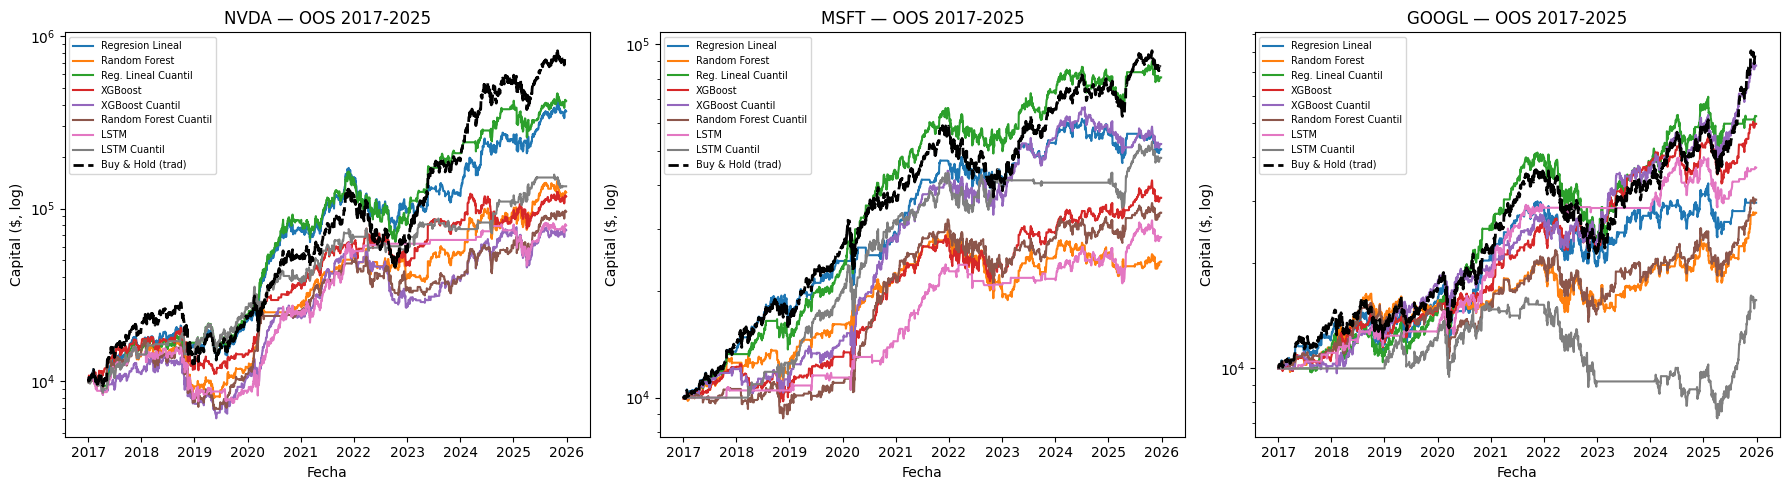

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ticker in zip(axes, TICKERS):
    for nombre in MODELOS:
        ax.plot(curvas_ml[(ticker, nombre)], label=nombre)
    ax.plot(curvas_trad[(ticker, 'Buy & Hold')], 'k--', lw=2, label='Buy & Hold (trad)')
    ax.set_yscale('log'); ax.set_title(f'{ticker} — OOS {AÑO_INICIO_OOS}-{AÑO_FIN_OOS}')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Capital ($, log)'); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

<!-- __SHAP_CELL__ -->
## 12. SHAP — Interpretación de variables (Objetivo 1)

La selección de las 9 variables la hicieron **VIF + ADF** (sin usar el *target*), de modo que SHAP es
**puramente interpretativo**: no selecciona, solo explica cuánto aporta cada variable a la predicción
del retorno. Se entrena un modelo sobre **toda la serie** de cada acción y se explica por tres ejes:
por **acción** (tres *beeswarm*, la Figura 9), por **algoritmo** (XGBoost vs Random Forest vs
Regresión Lineal) y por **periodo** (mean|SHAP| año a año). Las figuras se guardan en `figuras/`.

[NVDA] filas=3720  2011-03-16..2025-12-29


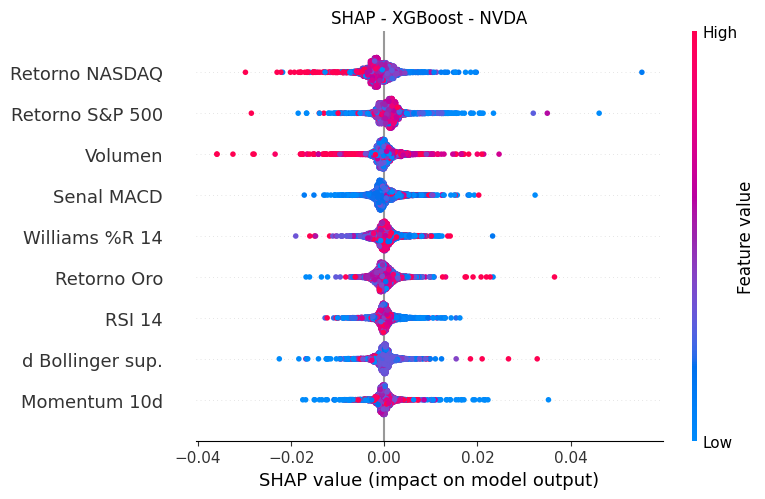

[MSFT] filas=3720  2011-03-16..2025-12-29


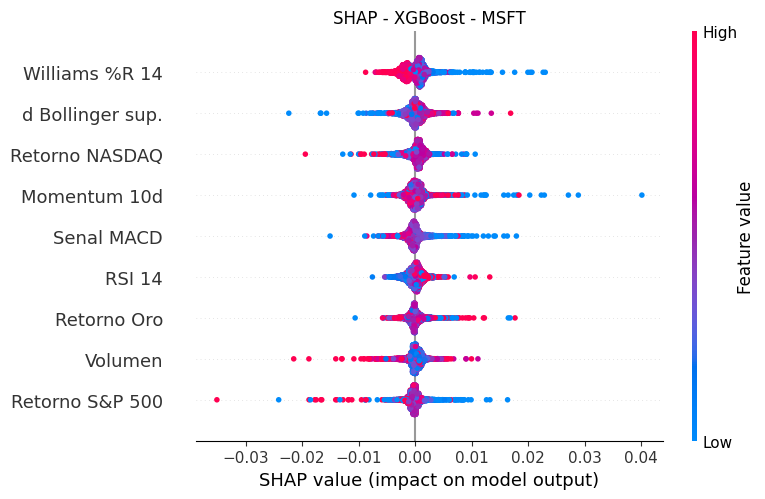

[GOOGL] filas=3720  2011-03-16..2025-12-29


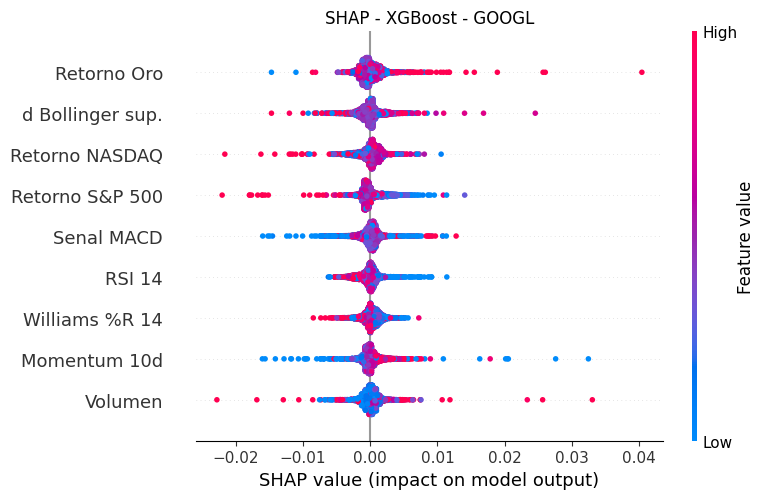

In [14]:
# __SHAP_CELL__  (1/2) beeswarm por accion (Figura 9) + importancias por algoritmo y por anio
from pathlib import Path
FIG_DIR = Path('figuras'); FIG_DIR.mkdir(exist_ok=True)
TARGET = 'Target_Retorno_1d'
NICE = {'BB_upper_diff': 'd Bollinger sup.', 'Gold_ret': 'Retorno Oro', 'MACD_signal': 'Senal MACD',
        'Momentum_10': 'Momentum 10d', 'NASDAQ_ret': 'Retorno NASDAQ', 'RSI_14': 'RSI 14',
        'SP500_ret': 'Retorno S&P 500', 'Volume': 'Volumen', 'WilliamsR_14': 'Williams %R 14'}

def _mean_abs(sv): return np.abs(np.asarray(sv)).mean(axis=0)
def _share(v):
    s = v.sum(); return 100.0 * v / s if s > 0 else v

filas_imp, filas_anio, share_xgb = [], [], {}

for ticker in TICKERS:
    df = cargar(ticker)
    X = df[FEATURES].copy(); y = df[TARGET].copy()
    Xplot = X.rename(columns=NICE)
    print(f'[{ticker}] filas={len(X)}  {X.index.min().date()}..{X.index.max().date()}')

    # --- XGBoost: modelo principal de interpretacion (Figura 9) ---
    xgb = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                       colsample_bytree=0.8, random_state=0, tree_method='hist').fit(X.values, y.values)
    sv = shap.TreeExplainer(xgb).shap_values(X.values)
    plt.figure()
    shap.summary_plot(sv, Xplot, show=False)
    plt.title(f'SHAP - XGBoost - {ticker}'); plt.tight_layout()
    plt.savefig(FIG_DIR / f'figura9_shap_beeswarm_{ticker}.png', dpi=160, bbox_inches='tight')
    plt.show()

    ma = _mean_abs(sv); share_xgb[ticker] = pd.Series(_share(ma), index=FEATURES)

    # --- Random Forest y Reg. Lineal: eje "por algoritmo" ---
    rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0).fit(X.values, y.values)
    ma_rf = _mean_abs(shap.TreeExplainer(rf).shap_values(X.values))
    sc = StandardScaler().fit(X.values); Xs = sc.transform(X.values)
    lin = LinearRegression().fit(Xs, y.values)
    ma_lin = _mean_abs(lin.coef_ * (Xs - Xs.mean(axis=0)))   # SHAP exacto para modelo lineal

    for modelo, m in [('XGBoost', ma), ('Random Forest', ma_rf), ('Reg. Lineal', ma_lin)]:
        sh = _share(m); orden = np.argsort(-m)
        rank = np.empty(len(m), int); rank[orden] = np.arange(1, len(m) + 1)
        for j, f in enumerate(FEATURES):
            filas_imp.append({'Accion': ticker, 'Modelo': modelo, 'Variable': f,
                              'mean_abs_shap': m[j], 'share_pct': sh[j], 'rank': rank[j]})

    # --- mean|SHAP| por anio (XGBoost): tercer eje del Objetivo 1 ---
    svdf = pd.DataFrame(np.abs(sv), index=X.index, columns=FEATURES)
    for anio, row in svdf.groupby(svdf.index.year).mean().iterrows():
        sh = _share(row.values)
        for j, f in enumerate(FEATURES):
            filas_anio.append({'Accion': ticker, 'Anio': int(anio), 'Variable': f,
                               'mean_abs_shap': row.values[j], 'share_pct': sh[j]})


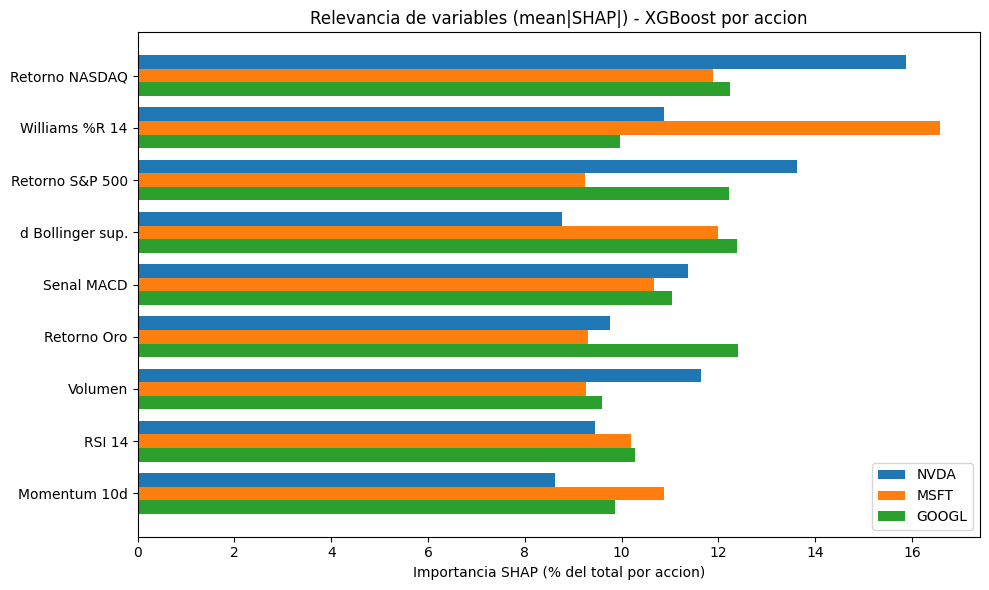

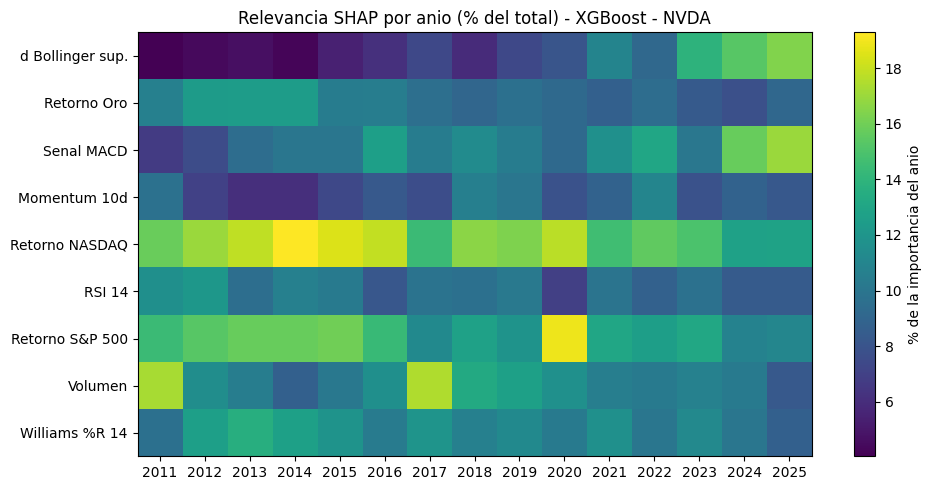

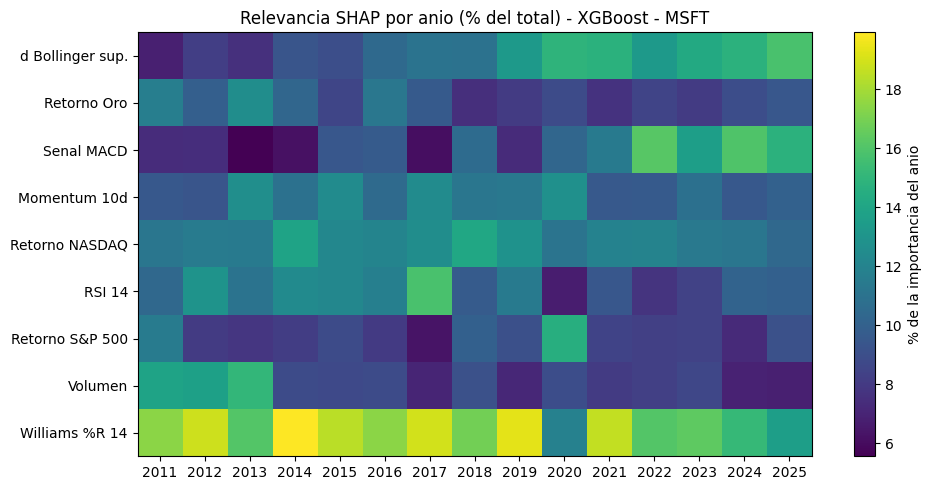

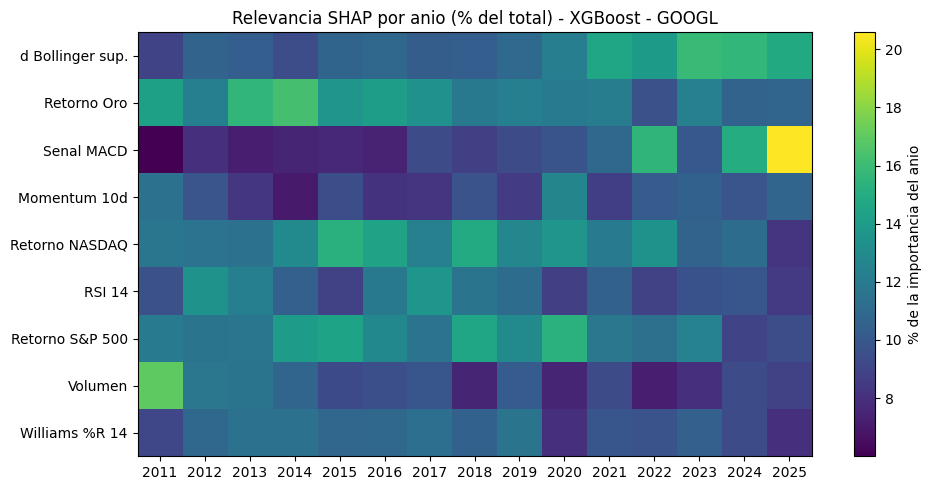

==== Ranking de importancia (XGBoost, share %) ====

NVDA:
   1. NASDAQ_ret       15.9%
   2. SP500_ret        13.6%
   3. Volume           11.6%
   4. MACD_signal      11.4%
   5. WilliamsR_14     10.9%
   6. Gold_ret          9.8%
   7. RSI_14            9.4%
   8. BB_upper_diff     8.8%
   9. Momentum_10       8.6%

MSFT:
   1. WilliamsR_14     16.6%
   2. BB_upper_diff    12.0%
   3. NASDAQ_ret       11.9%
   4. Momentum_10      10.9%
   5. MACD_signal      10.7%
   6. RSI_14           10.2%
   7. Gold_ret          9.3%
   8. Volume            9.3%
   9. SP500_ret         9.2%

GOOGL:
   1. Gold_ret         12.4%
   2. BB_upper_diff    12.4%
   3. NASDAQ_ret       12.2%
   4. SP500_ret        12.2%
   5. MACD_signal      11.0%
   6. RSI_14           10.3%
   7. WilliamsR_14     10.0%
   8. Momentum_10       9.9%
   9. Volume            9.6%

==== Top-3 por accion y algoritmo (consistencia) ====

NVDA:
  XGBoost       : NASDAQ_ret(16%), SP500_ret(14%), Volume(12%)
  Random Forest : 

In [15]:
# __SHAP_CELL__  (2/2) barra comparativa + mapas de calor por anio + CSV + ranking
imp = pd.DataFrame(filas_imp); imp.to_csv('shap_importancia.csv', index=False)
pd.DataFrame(filas_anio).to_csv('shap_por_anio.csv', index=False)

# --- Barra comparativa: importancia XGBoost normalizada, 3 acciones ---
comp = pd.DataFrame(share_xgb)
comp = comp.loc[comp.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(10, 6)); ypos = np.arange(len(comp.index)); w = 0.26
for k, t in enumerate(TICKERS):
    ax.barh(ypos + (k - 1) * w, comp[t].values, height=w, label=t)
ax.set_yticks(ypos); ax.set_yticklabels([NICE[f] for f in comp.index]); ax.invert_yaxis()
ax.set_xlabel('Importancia SHAP (% del total por accion)')
ax.set_title('Relevancia de variables (mean|SHAP|) - XGBoost por accion'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / 'figura_shap_barras_comparativa.png', dpi=160, bbox_inches='tight'); plt.show()

# --- Mapa de calor relevancia x anio, por accion ---
anio_df = pd.DataFrame(filas_anio)
for t in TICKERS:
    piv = anio_df[anio_df.Accion == t].pivot(index='Variable', columns='Anio', values='share_pct').loc[FEATURES]
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(piv.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels([NICE[f] for f in piv.index])
    ax.set_title(f'Relevancia SHAP por anio (% del total) - XGBoost - {t}')
    fig.colorbar(im, ax=ax, label='% de la importancia del anio')
    plt.tight_layout(); plt.savefig(FIG_DIR / f'figura_shap_por_anio_{t}.png', dpi=160, bbox_inches='tight'); plt.show()

# --- Ranking legible para redactar el Cap. 7 ---
print('==== Ranking de importancia (XGBoost, share %) ====')
for t in TICKERS:
    sub = imp[(imp.Accion == t) & (imp.Modelo == 'XGBoost')].sort_values('rank')
    print(f'\n{t}:')
    for _, r in sub.iterrows():
        print(f"  {int(r['rank']):>2}. {r.Variable:<15} {r.share_pct:5.1f}%")

print('\n==== Top-3 por accion y algoritmo (consistencia) ====')
for t in TICKERS:
    print(f'\n{t}:')
    for mod in ['XGBoost', 'Random Forest', 'Reg. Lineal']:
        sub = imp[(imp.Accion == t) & (imp.Modelo == mod)].sort_values('rank').head(3)
        print(f"  {mod:<14}: " + ', '.join(f'{r.Variable}({r.share_pct:.0f}%)' for _, r in sub.iterrows()))
